In [11]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../data/2D/chunk_000.npz", allow_pickle=True)
snaps      = d["snaps"]          # (50, 33, 128, 128)
snap_times = d["snap_times"]     # (33,)
phi_final  = d["phi_final"]      # (50, 128, 128)

print(snaps.shape, phi_final.shape)

(50, 33, 128, 128) (50, 128, 128)


In [15]:
def make_xy(c):
    """c = index of the window center in snap_times (5, 16, or 27)."""
    X = snaps[:, c]                                  # (n, 5, 128, 128)
    Y = (phi_final > 0).astype(np.float32)[:, None]        # (n, 1, 128, 128)
    return X, Y

X, Y = make_xy(16)
print(X.shape, Y.shape, "times:", snap_times[14:19])
print("fraction of +1 sites:", Y.mean())

(50, 128, 128) (50, 1, 128, 128) times: [48 49 50 51 52]
fraction of +1 sites: 0.58360595


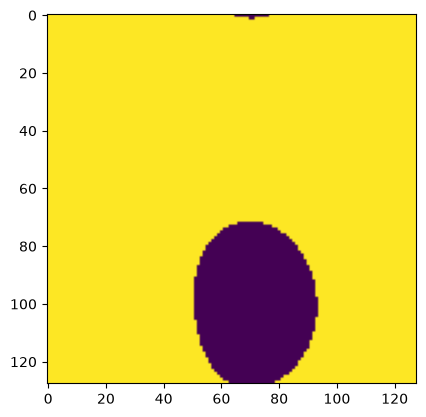

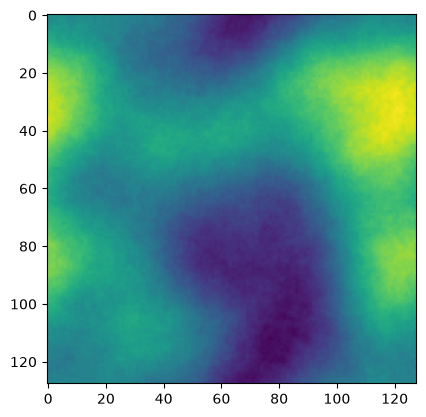

In [18]:
plt.imshow(Y[0][0])
plt.show()
plt.imshow(X[0])

In [19]:
import torch
import torch.nn as nn

X = torch.from_numpy(snaps[:, 16:17])                        # (50, 1, 128, 128)
Y = torch.from_numpy((phi_final > 0).astype(np.float32)[:, None])

In [20]:
t_in = 50                                    # which time to use as input
i    = np.where(snap_times == t_in)[0][0]    # its index in snaps

X = snaps[:, i]                              # (50, 128, 128)  one snapshot per sample
Y = (phi_final > 0).astype(np.float32)       # (50, 128, 128)  final sign map

print("input time:", snap_times[i], X.shape, Y.shape)

input time: 50 (50, 128, 128) (50, 128, 128)


In [21]:
X_t = torch.from_numpy(X[:, None])      # (50, 1, 128, 128)
Y_t = torch.from_numpy(Y[:, None])      # (50, 1, 128, 128)

In [50]:
def block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1, padding_mode="circular"), nn.ReLU(),
        nn.Conv2d(c_out, c_out, 3, padding=1, padding_mode="circular"), nn.ReLU(),
    )

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2)

        # going down
        self.down1  = block(1, 16)
        self.down2  = block(16, 32)
        self.down3  = block(32, 64)
        self.bottom = block(64, 128)

        # going up (input channels = upsampled + skip)
        self.up3 = block(128 + 64, 64)
        self.up2 = block(64 + 32, 32)
        self.up1 = block(32 + 16, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)                                   # (16, 128, 128)
        d2 = self.down2(self.pool(d1))                       # (32,  64,  64)
        d3 = self.down3(self.pool(d2))                       # (64,  32,  32)
        b  = self.bottom(self.pool(d3))                      # (128, 16,  16)

        u3 = self.up3(torch.cat([self.up(b),  d3], dim=1))   # (64,  32,  32)
        u2 = self.up2(torch.cat([self.up(u3), d2], dim=1))   # (32,  64,  64)
        u1 = self.up1(torch.cat([self.up(u2), d1], dim=1))   # (16, 128, 128)
        return self.out(u1)                                  # (1,  128, 128)

model = UNet()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model(X_t[:2]).shape)    # should be (2, 1, 128, 128)

torch.Size([2, 1, 128, 128])


In [51]:
print(model)                                   # layer list
for name, p in model.named_parameters():
    print(name, p.shape)                       # e.g. net.0.weight (16, 1, 3, 3)

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (up): Upsample(scale_factor=2.0, mode='nearest')
  (down1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (3): ReLU()
  )
  (down2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (3): ReLU()
  )
  (down3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (3): ReLU()
  )
  (bottom): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [52]:
loss_fn = nn.BCEWithLogitsLoss()

X_t = X_t / X_t.std()


In [54]:
for epoch in range(300):
    logits = model(X_t)              # 1. predict
    loss   = loss_fn(logits, Y_t)    # 2. how wrong
    opt.zero_grad()                  # 3. clear old gradients
    loss.backward()                  # 4. compute gradients
    opt.step()                       # 5. update weights

    if epoch % 30 == 0:
        acc = ((logits > 0) == (Y_t > 0.5)).float().mean().item()
        print(f"epoch {epoch:3d}   loss {loss.item():.4f}   acc {acc:.3f}")

epoch   0   loss 0.2367   acc 0.906
epoch  30   loss 0.0947   acc 0.961


KeyboardInterrupt: 

model: 0.861   baseline: 0.858


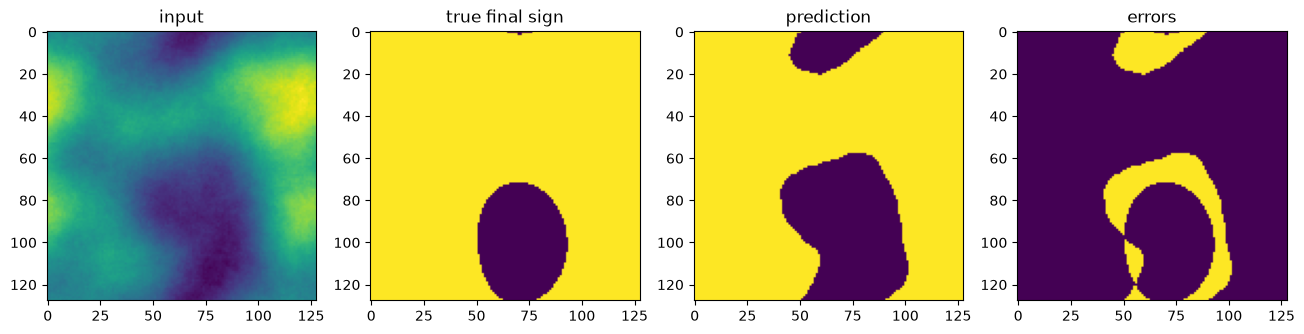

In [45]:
with torch.no_grad():
    pred = model(X_t) > 0

acc  = (pred == (Y_t > 0.5)).float().mean().item()
base = ((X_t > 0) == (Y_t > 0.5)).float().mean().item()
print(f"model: {acc:.3f}   baseline: {base:.3f}")

n = 0
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(X_t[n, 0]);             axes[0].set_title("input")
axes[1].imshow(Y_t[n, 0]);             axes[1].set_title("true final sign")
axes[2].imshow(pred[n, 0]);            axes[2].set_title("prediction")
axes[3].imshow(pred[n, 0] != (Y_t[n, 0] > 0.5)); axes[3].set_title("errors")
plt.show()